# 1. Préliminaires

## 1.1. Contexte 

Student Exam Performance Dataset Analysis : [Dataset](https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis/data)
Ce dataset utilisé dans ce repository pour pratiquer l'analyse de donnée.

## 1.2 Importations des librairies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1.3 Chargement des données

In [2]:
# chargement des données
data = pd.read_csv('./data/StudentPerformanceFactors.csv')

# Affichage d'un extrait
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 1.4 Structure et typologie des données
Affichage des dimensions et types des colonnes.

In [3]:
# Affichage des dimensions du dataframe
data.shape

(6607, 20)

In [4]:
# Affichage des informations sur les colonnes
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# 2. Analyse Exploratoire des données
Nous allons réaliser une analyse exploratoire des données.

## 2.1 Changement du type de certaines colonnes

In [5]:
categorical_cols = [
    "Distance_from_Home",
    "Gender",
    "Parental_Education_Level",
    "Teacher_Quality",
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Internet_Access",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Family_Income"
]
data[categorical_cols] = data[categorical_cols].astype("category")

data[categorical_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Distance_from_Home        6540 non-null   category
 1   Gender                    6607 non-null   category
 2   Parental_Education_Level  6517 non-null   category
 3   Teacher_Quality           6529 non-null   category
 4   Parental_Involvement      6607 non-null   category
 5   Access_to_Resources       6607 non-null   category
 6   Motivation_Level          6607 non-null   category
 7   Internet_Access           6607 non-null   category
 8   School_Type               6607 non-null   category
 9   Peer_Influence            6607 non-null   category
 10  Learning_Disabilities     6607 non-null   category
 11  Family_Income             6607 non-null   category
dtypes: category(12)
memory usage: 78.1 KB


## 2.2 Exploration et Nettoyage
Ici nous allons explorer les données et faire du nettoyage.

In [6]:
# Affichage des statistiques de la méthode .describe()
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
# verification des valeurs nan
data.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [8]:
# Suppresion des valeurs manquantes
data.dropna(subset=['Teacher_Quality','Distance_from_Home','Parental_Education_Level'],inplace=True)

In [9]:
data.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [10]:
# verification de la suppression des valeurs nulles
display("Somme des valeurs manquantes",data.isnull().sum())
display("Nouvelles dimensions ",data.shape)

'Somme des valeurs manquantes'

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

'Nouvelles dimensions '

(6378, 20)

In [11]:
# verifications des valeurs dupliquées
data.duplicated().sum()

np.int64(0)

In [ ]:
# verification du nombre des valeurs uniques
data.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

In [ ]:
# Verification du nombre des valeurs de Tutoring_Sessions vu que le maximum est très éloigné du troisième quartile
data.loc[data["Tutoring_Sessions"]>2,"Tutoring_Sessions"].value_counts()

Tutoring_Sessions
3    800
4    296
5    101
6     18
7      7
8      1
Name: count, dtype: int64

 ## 2.3 Analyse Univariée

Nous allons étudier certaines variables individuellement.

Nous allons d'abord créer des fonctions qui nous aideront pour les graphiques.

In [ ]:
# Cette fonction retourne un diagramme circulaire

def get_pie_repartition_chart(series:pd.Series,title:str,palette:str):
    """_summary_

    Args:
        series (pd.Series): la series à utiliser.
        title (str): le titre du graphique
        palette (str): le nom de la palette de couleur
    """

    # On récupère les comptes
    count = series.value_counts()

    # Récupération des labels
    labels = count.index.to_list()

    # Choix de la palette de couleur
    colors = sns.color_palette(palette,n_colors=len(labels))

    # Initialisation de la figure
    plt.figure(figsize=(9,6))

    # Pie chart avec un pourcentage 2 chiffres après la virgule et un angle qui commence à 90
    plt.pie(count,autopct='%1.2f%%',startangle=90,labels=labels,colors=colors)

    # Titre du graphique
    plt.title(title)

    # Affichage du graphique
    plt.show()

### 2.3.1 Graphique sur la repartition par genre

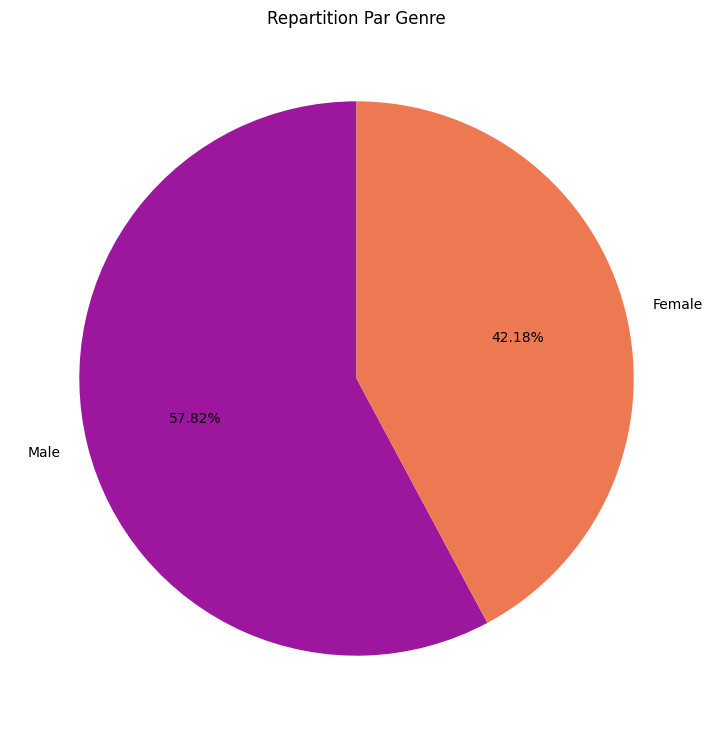

In [48]:
get_pie_repartition_chart(
    series=data["Gender"], title="Repartition Par Genre", palette="plasma"
)

**Interprétation** :  

On remarque une plus grande proportion dans le sexe masculin. 

### 2.3.2 Graphique sur la repartition par Distance depuis la maison

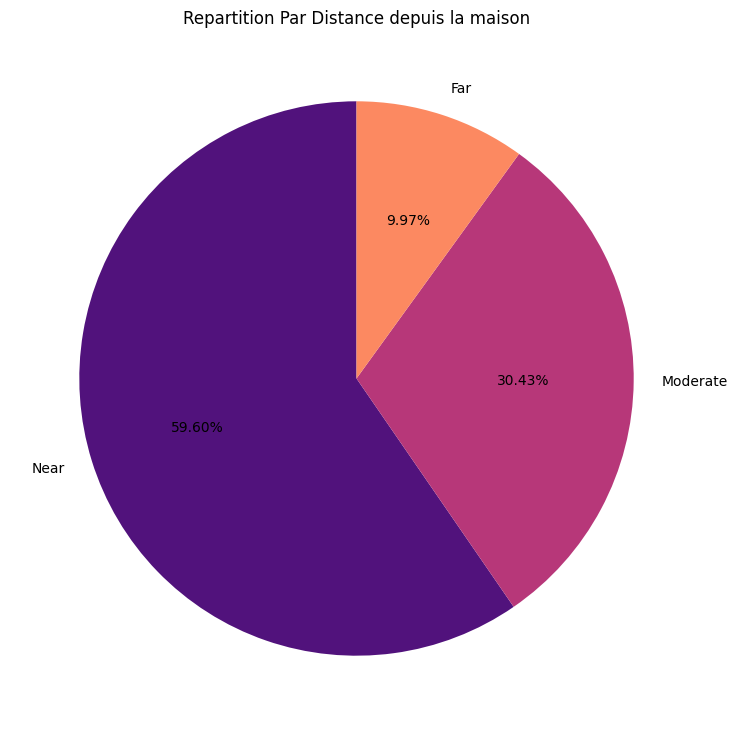

In [49]:
get_pie_repartition_chart(
    series=data["Distance_from_Home"],
    title="Repartition Par Distance depuis la maison",
    palette="magma",
)

**Interprétation** : 

On remarque que plus de la moitié des étudiants habitent pas loin.
Une part significative habite à une distance modérée et une part non négligeable habite loin. 

### 2.3.3 Graphique sur la repartition par Le niveau d'education des parents

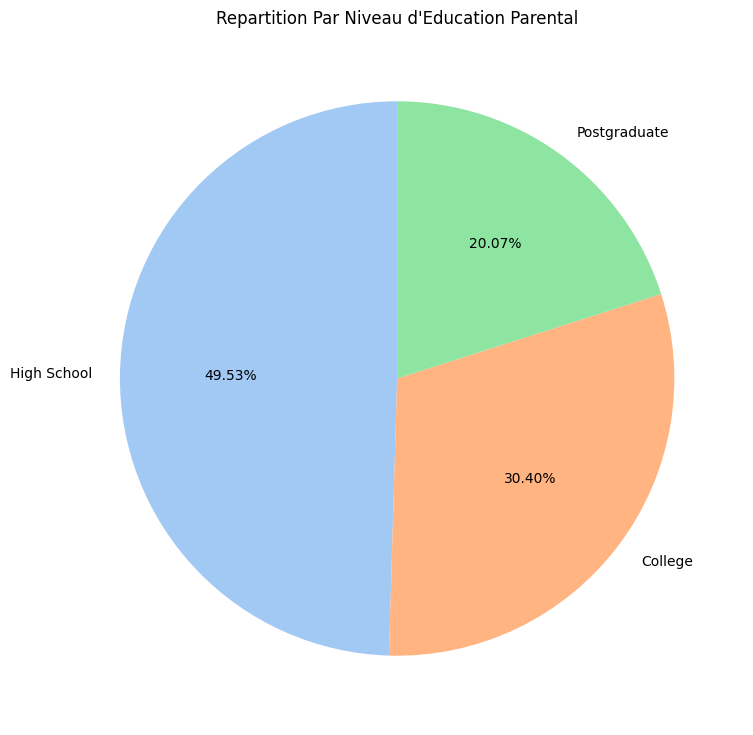

In [51]:
get_pie_repartition_chart(
    series=data["Parental_Education_Level"],
    title="Repartition Par Niveau d'Education Parental",
    palette="pastel",
)

**Interprétation** : 

On remarque que beaucoup de parent se sont arretés au lycée et une part considerable au collège et que peu ont atteri aux études universitaires.

### 2.3.4 Graphique sur la repartition par La présence ou non de difficulté d'apprentissage

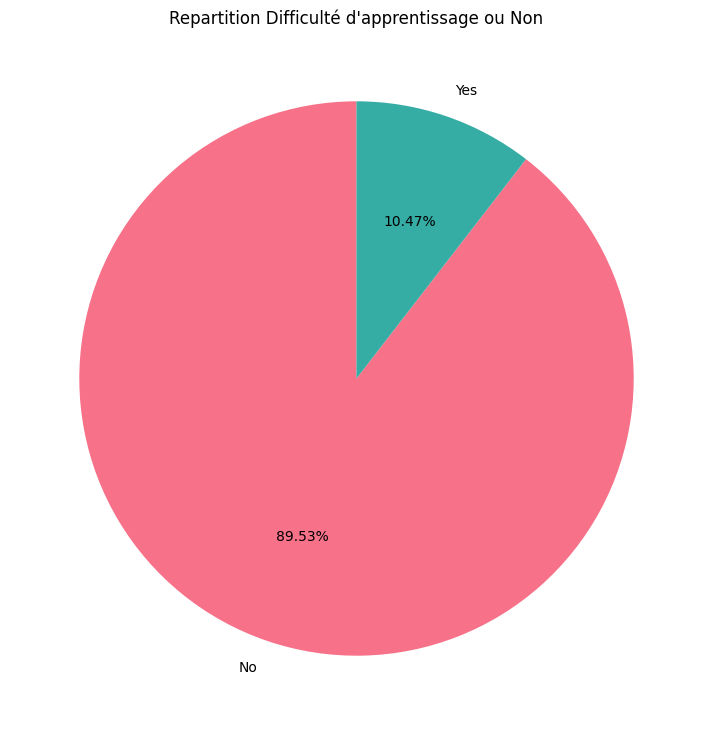

In [ ]:
get_pie_repartition_chart(
    series=data["Learning_Disabilities"],
    title="Repartition  par Difficulté d'apprentissage ou Non",
    palette="husl",
)

**Interprétation** : 

On remarque la présence d'une minorité qui a des difficultés d'apprentissage.

### 2.3.5 Graphique sur la repartition par Influence de l'entourage



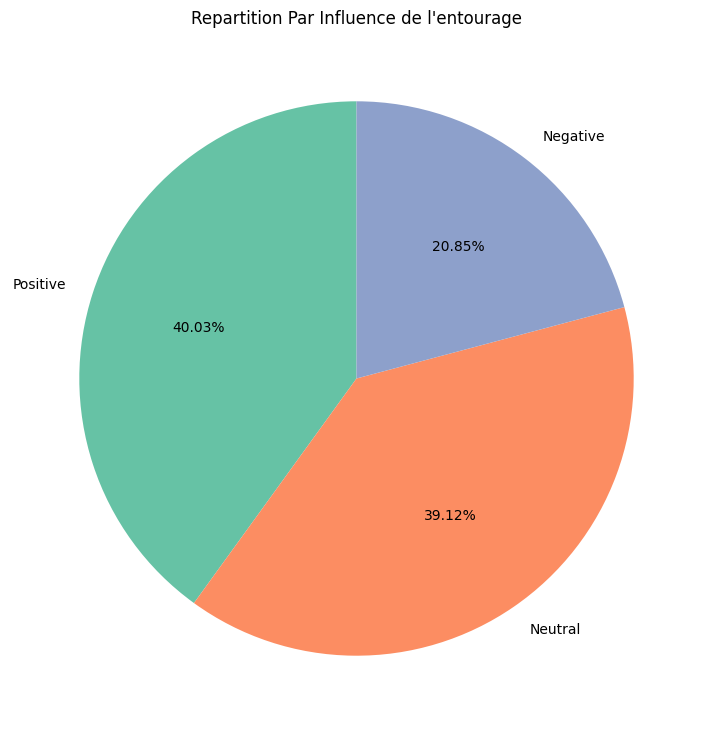

In [54]:
get_pie_repartition_chart(
    series=data["Peer_Influence"],
    title="Repartition Par Influence de l'entourage",
    palette="Set2",
)

**Interprétation** : 
La majorité des étudiants ont un  entourage avec une influence positive , mais une partie aussi conséquente est neutre et une non négligeable est négative.

### 2.3.6 Graphique sur la repartition par Par Implication des parents

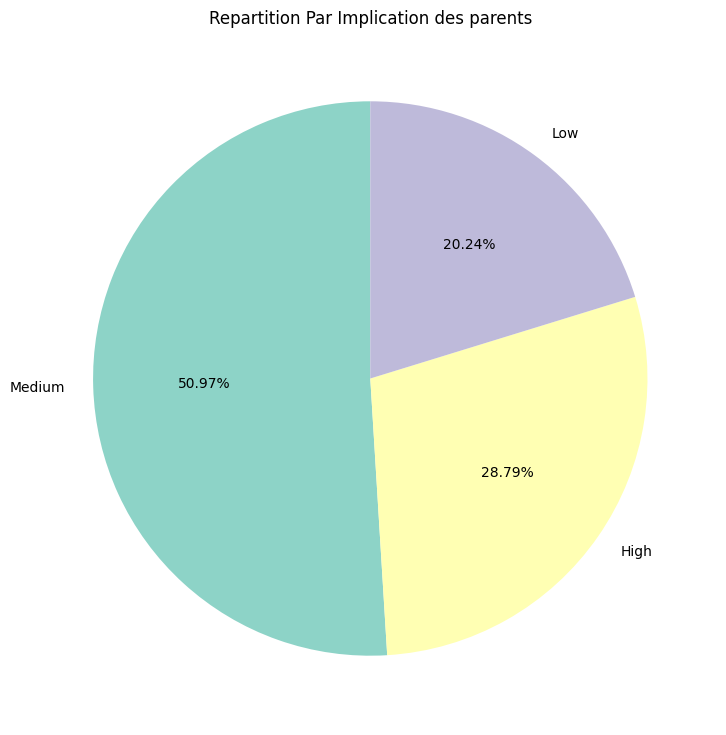

In [67]:
get_pie_repartition_chart(
    series=data["Parental_Involvement"],
    title="Repartition Par Implication des parents",
    palette="Set3",
)

**Interprétation** : 
Plus de la moitié ont leurs parents impliqués et une partie a les parents très impliqués mais une part négligeable a une implication moins présente des parents.

### 2.3.7 Graphique sur la repartition par Par Accès aux ressources

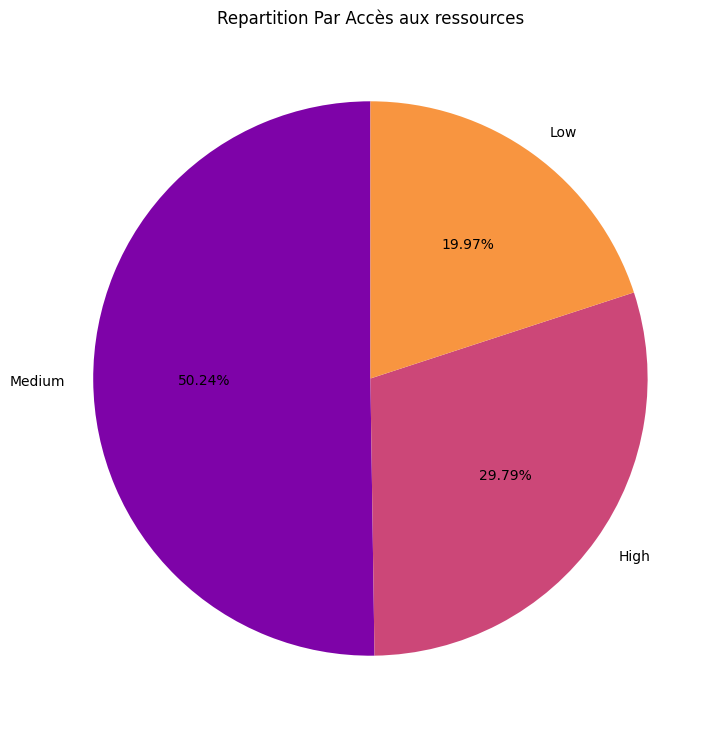

In [57]:
get_pie_repartition_chart(
    series=data["Access_to_Resources"],
    title="Repartition Par Accès aux ressources",
    palette="plasma",
)

**Interprétation** : 
Une part importante à un accès moyen aux ressources et une autre un peu moins à un accès très élevé et on a une minorité avec un accès faible.

### 2.3.8 Graphique sur la repartition par Pratique ou Non d'activités extrascolaires

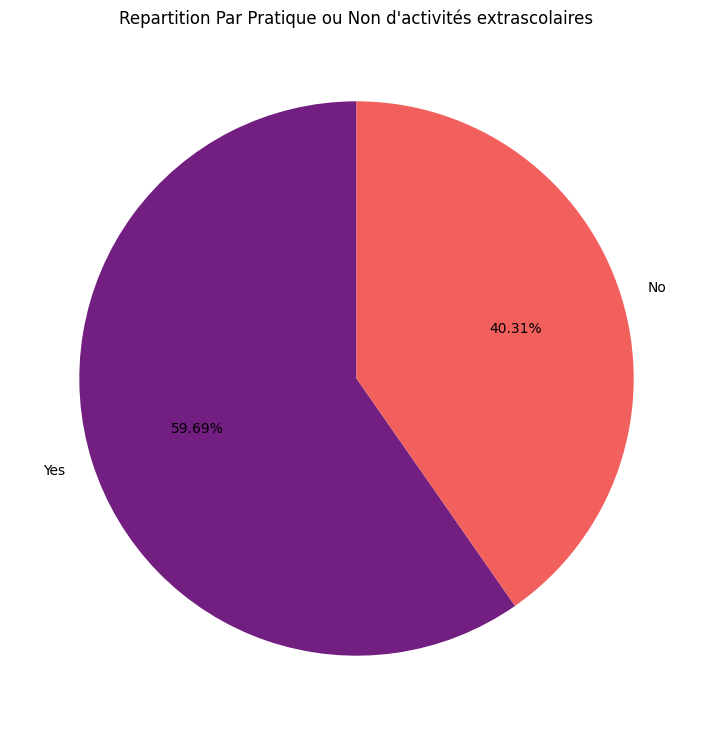

In [59]:
get_pie_repartition_chart(
    series=data["Extracurricular_Activities"],
    title="Repartition Par Pratique ou Non d'activités extrascolaires",
    palette="magma",
)

**Interprétation** : 

Plus de la moitié pratiquenet des activités extrascolaires.

### 2.3.9 Graphique sur la repartition par Niveau de motivation

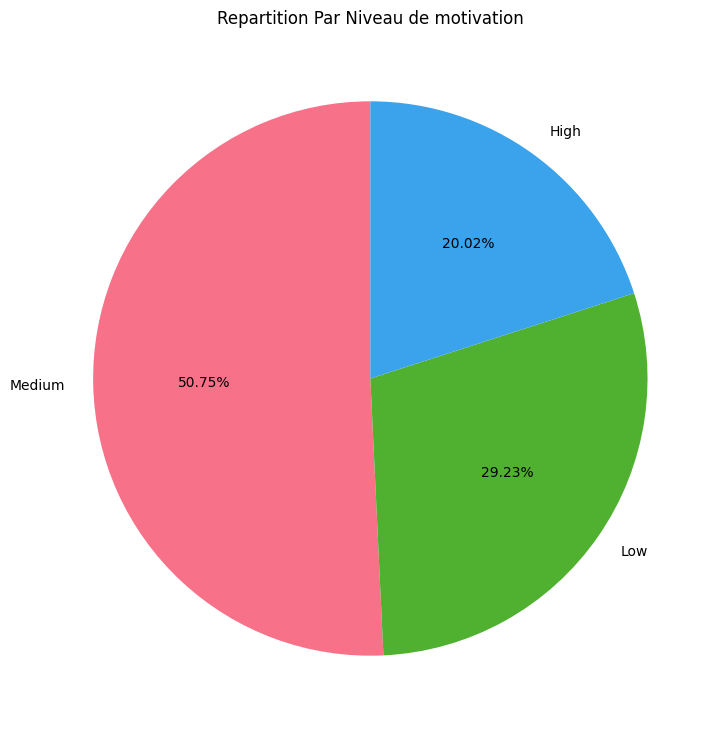

In [61]:
get_pie_repartition_chart(
    series=data["Motivation_Level"],
    title="Repartition Par Niveau de motivation",
    palette="husl",
)

**Interprétation** : 
Plus de la moitié ont un niveau de motivation moyen et une part moins élevée pour un niveau de motivation faible et une part faible à un niveau de motivation élevé.

### 2.3.10 Graphique sur la repartition par Accès à internet

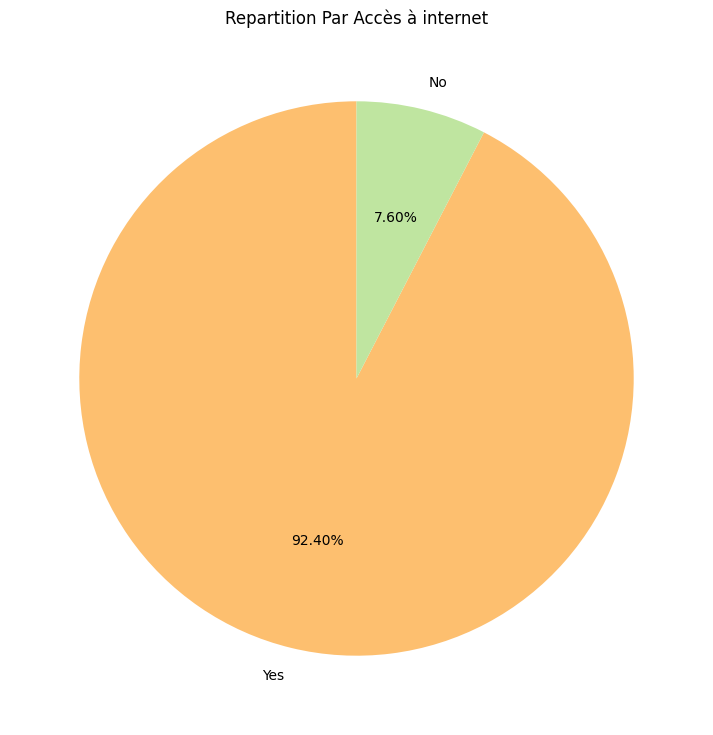

In [63]:
get_pie_repartition_chart(
    series=data["Internet_Access"],
    title="Repartition Par Accès à internet",
    palette="Spectral",
)

**Interprétation** : 
Une majorité des étudiants ont accès à internet , et une  minorité non.

### 2.3.11 Graphique sur la repartition par Niveau de Revenu Familiale

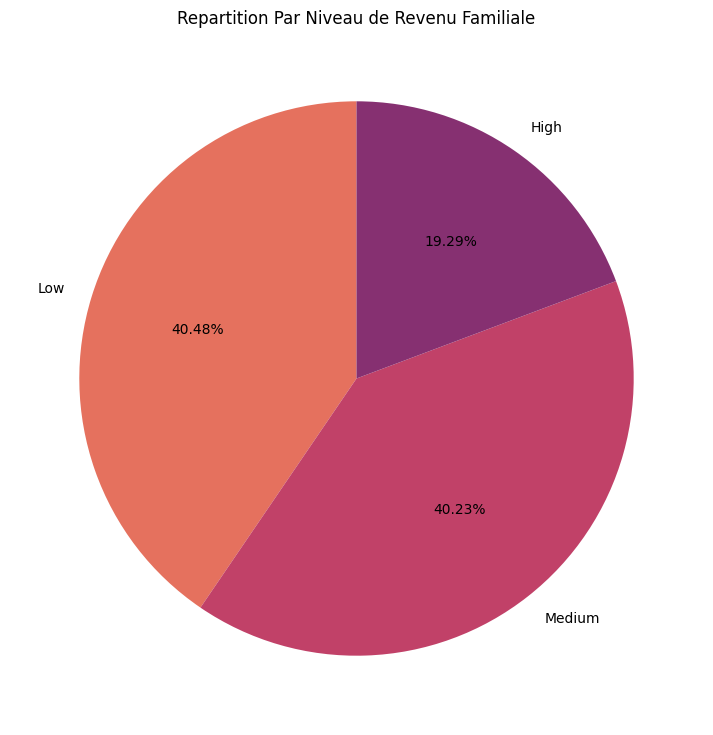

In [64]:
get_pie_repartition_chart(
    series=data["Family_Income"],
    title="Repartition Par Niveau de Revenu Familiale",
    palette="flare",
)

**Interprétation** : 
On a deux grand groupes : l'un pour les étudiants avec un revenu familiale faible et l'autre avec un revenu  modéré . Ensuite on a une minorité aisé.

### 2.3.12 Graphique sur la repartition par Par Niveau de Qualité du Professeur

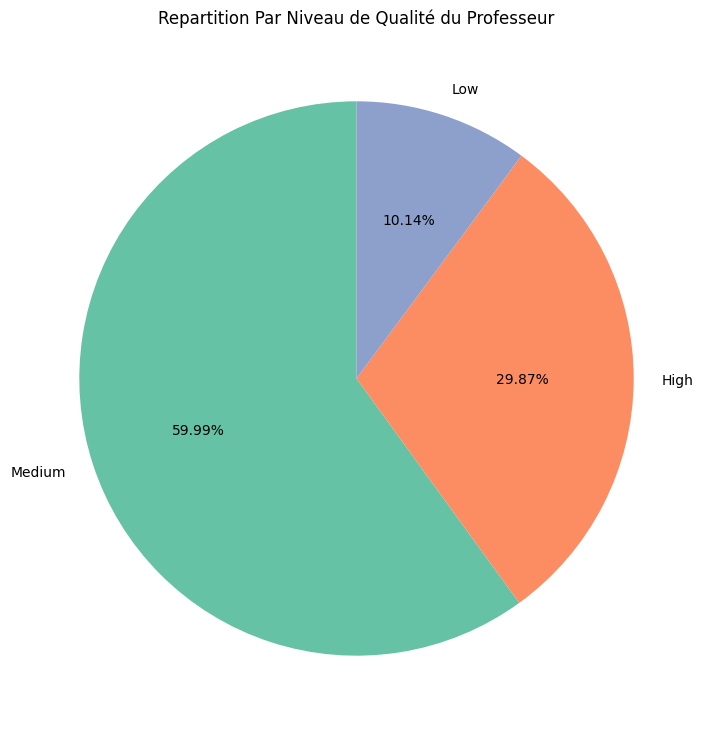

In [65]:
get_pie_repartition_chart(
    series=data["Teacher_Quality"],
    title="Repartition Par Niveau de Qualité du Professeur",
    palette="Set2",
)

**Interprétation** : 
La plupart des étudiants ont des  professeurs de qualité moyenne et une autre proportion moins représentée a des très professeurs et une faible proportion des professeurs avec un niveau médiocre.

### 2.3.13 Graphique sur la repartition par Type d'Université

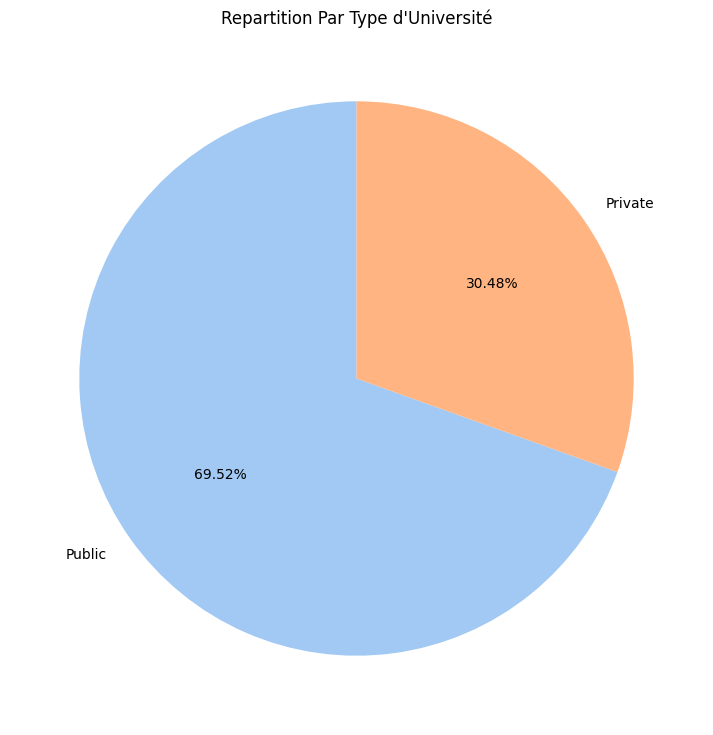

In [66]:
get_pie_repartition_chart(
    series=data["School_Type"],
    title="Repartition Par Type d'Université",
    palette="pastel",
)

**Interprétation** : 
Il y a significativement plus d'etudiants dans des universités plubliques que privés.

# 3. Reduction de dimension et segmentation
On va faire ACP et clustering .

## 3.1 Sélection des variables quantitatives

In [14]:
# Choix des colonnes
cols = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score",
]

# On obtient un nouveau dataframe df
df = data[cols]

# Affichage d'un extrait de df
df.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70


## 3.2 Standarisation   
Ici on va standariser les données.

In [15]:
# Ici on a la matrice des données X
X = df.values

# Affichage d'un extrait de X
X[:5]

array([[23, 84,  7, 73,  0,  3, 67],
       [19, 64,  8, 59,  2,  4, 61],
       [24, 98,  7, 91,  2,  4, 74],
       [29, 89,  8, 98,  1,  4, 71],
       [19, 92,  6, 65,  3,  4, 70]])

In [16]:
# Instancions notre scaler
scaler = StandardScaler()

# Ici on a la matrice centrée et réduite
X_Scaled = scaler.fit_transform(X)

In [17]:
# Verification de la standarisation
pd.DataFrame(X_Scaled).describe().round().loc[['mean','std']]

,0,1,2,3,4,5,6
mean,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0
